In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r"/Users/shubham/Desktop/ML_REPO/Bank Customer Churn/customer-churn-data/Bank Customer Churn Prediction.csv")
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

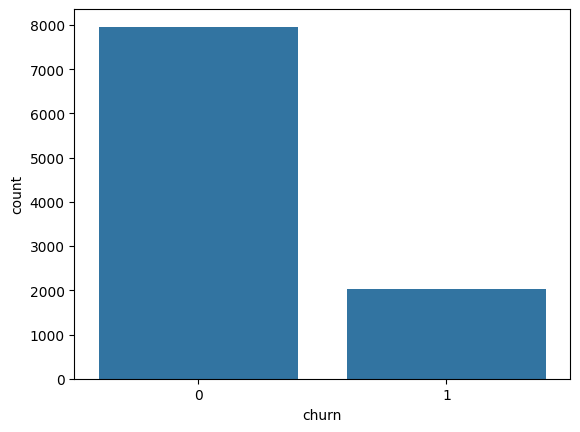

In [4]:
sns.countplot(x=df["churn"])
plt.show()

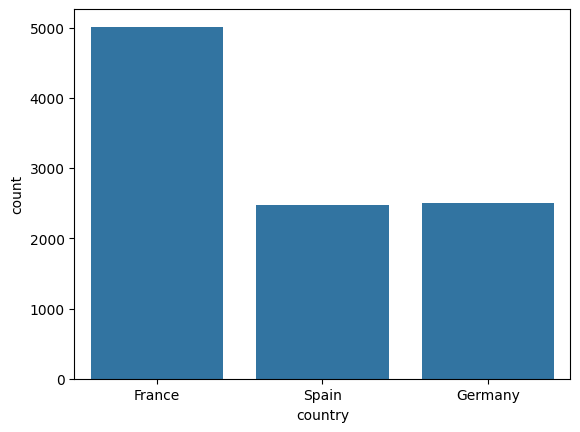

In [5]:
sns.countplot(x=df["country"])
plt.show()

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 937.6 KB


# Preprocessing

In [7]:
df.drop(columns=["customer_id"],inplace=True)

In [8]:
df = pd.get_dummies(df, columns=["country"], drop_first=True,  dtype=int)

In [9]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [10]:
# LabelEncoder.fit_transform(y) only accepts one argument ().
# When a Pipeline calls it, it passes both and leading to your error: 
# TypeError: fit_transform() takes 2 positional arguments but 3 were given


df["gender"] = LabelEncoder().fit_transform(df["gender"])

In [11]:
y = df['churn']
X = df.drop(columns=['churn'])

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
X_train_scaled.shape

(8000, 11)

# Neural Network

In [15]:
import torch
import torch.nn as nn

In [16]:
class bank_churn_model(nn.Module):
    def __init__(self, input_dim, output_dim,number_of_hidden_units, number_of_hidden_layer, dropout_rate):
        super().__init__()


        model_layers = []
        for i in range(number_of_hidden_layer):
            model_layers.append(nn.Linear(input_dim, number_of_hidden_units))
            model_layers.append(nn.BatchNorm1d(number_of_hidden_units))
            model_layers.append(nn.ReLU())
            model_layers.append(nn.Dropout(dropout_rate))
            input_dim = number_of_hidden_units

        model_layers.append(nn.Linear(number_of_hidden_units, output_dim))
        model_layers.append(nn.Sigmoid())


        self.model = nn.Sequential(*model_layers)

    def forward(self, x):
        x = self.model(x)
        return x

In [17]:
from torch.utils.data import Dataset, DataLoader
class bank_churn_dataset(Dataset):
    def __init__(self,features,labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self):
        return len(self.features)
    def __getitem__(self,idx):
        return self.features[idx], self.labels[idx]

In [18]:
train_dataset = bank_churn_dataset(X_train_scaled, y_train.values)
test_dataset = bank_churn_dataset(X_test_scaled, y_test.values)

train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [19]:
epochs = 20
input_dim = X_train_scaled.shape[1]
output_dim = 1
number_of_hidden_units = 64
number_of_hidden_layer = 2
dropout_rate = 0.2

In [20]:
model = bank_churn_model(input_dim, output_dim,number_of_hidden_units, number_of_hidden_layer, dropout_rate)
criterion = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

In [21]:
from torchinfo import summary
summary(model, input_size=(64, X_train_scaled.shape[1]))

Layer (type:depth-idx)                   Output Shape              Param #
bank_churn_model                         [64, 1]                   --
├─Sequential: 1-1                        [64, 1]                   --
│    └─Linear: 2-1                       [64, 64]                  768
│    └─BatchNorm1d: 2-2                  [64, 64]                  128
│    └─ReLU: 2-3                         [64, 64]                  --
│    └─Dropout: 2-4                      [64, 64]                  --
│    └─Linear: 2-5                       [64, 64]                  4,160
│    └─BatchNorm1d: 2-6                  [64, 64]                  128
│    └─ReLU: 2-7                         [64, 64]                  --
│    └─Dropout: 2-8                      [64, 64]                  --
│    └─Linear: 2-9                       [64, 1]                   65
│    └─Sigmoid: 2-10                     [64, 1]                   --
Total params: 5,249
Trainable params: 5,249
Non-trainable params: 0
Total mult-

In [22]:
for epoch in range(epochs):
    epoch_loss = 0.0
    for features, labels in train_dataloader:
        optimizer.zero_grad() # Clear the gradients
        outputs = model(features) 
        loss = criterion(outputs.squeeze(), labels.float())
        loss.backward()
        optimizer.step() # Update the model parameters
        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(train_dataloader):.4f}")

Epoch 1/20, Loss: 0.5377
Epoch 2/20, Loss: 0.4697
Epoch 3/20, Loss: 0.4533
Epoch 4/20, Loss: 0.4409
Epoch 5/20, Loss: 0.4371
Epoch 6/20, Loss: 0.4281
Epoch 7/20, Loss: 0.4258
Epoch 8/20, Loss: 0.4192
Epoch 9/20, Loss: 0.4137
Epoch 10/20, Loss: 0.4149
Epoch 11/20, Loss: 0.4095
Epoch 12/20, Loss: 0.4095
Epoch 13/20, Loss: 0.4045
Epoch 14/20, Loss: 0.4018
Epoch 15/20, Loss: 0.3941
Epoch 16/20, Loss: 0.3968
Epoch 17/20, Loss: 0.3919
Epoch 18/20, Loss: 0.3928
Epoch 19/20, Loss: 0.3835
Epoch 20/20, Loss: 0.3881


In [23]:
model.eval()
with torch.no_grad():
    correct = 0
    total = 0
    for features, labels in test_dataloader:
        outputs = model(features).squeeze()
        predicted = (outputs > 0.5).long()
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.8555


In [24]:
model.eval()
with torch.no_grad():
    correct = 0
    total = 0
    for features, labels in train_dataloader:
        outputs = model(features).squeeze()
        predicted = (outputs > 0.5).long()
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
print(f'Train Accuracy: {accuracy:.4f}')

Train Accuracy: 0.8548


In [25]:
import optuna

/Users/shubham/Desktop/ML_REPO/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [26]:
def objective(trial):
    number_of_hidden_units = trial.suggest_int("number_of_hidden_units", 32, 128)
    number_of_hidden_layer = trial.suggest_int("number_of_hidden_layer", 1, 3)
    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    momentum = trial.suggest_float("momentum", 0.5, 0.9)

    model = bank_churn_model(input_dim, output_dim,number_of_hidden_units, number_of_hidden_layer, dropout_rate)
    criterion = nn.BCELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum)

    for epoch in range(epochs):
        epoch_loss = 0.0
        for features, labels in train_dataloader:
            optimizer.zero_grad() # Clear the gradients
            outputs = model(features) 
            loss = criterion(outputs.squeeze(), labels.float())
            loss.backward()
            optimizer.step() # Update the model parameters
            epoch_loss += loss.item()

    model.eval()
    with torch.no_grad():
        correct = 0
        total = 0
        for features, labels in test_dataloader:
            outputs = model(features).squeeze()
            predicted = (outputs > 0.6).long()
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = correct / total
    return accuracy

In [27]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

[I 2026-04-01 15:30:26,575] A new study created in memory with name: no-name-facec417-3a0e-4112-ba24-61e206bec172
[I 2026-04-01 15:30:29,313] Trial 0 finished with value: 0.818 and parameters: {'number_of_hidden_units': 80, 'number_of_hidden_layer': 3, 'dropout_rate': 0.19386551234509578, 'learning_rate': 0.0006195410182558188, 'momentum': 0.6606260562897294}. Best is trial 0 with value: 0.818.
[I 2026-04-01 15:30:31,613] Trial 1 finished with value: 0.8035 and parameters: {'number_of_hidden_units': 75, 'number_of_hidden_layer': 2, 'dropout_rate': 0.4275838038973755, 'learning_rate': 0.00015272067664310988, 'momentum': 0.5796606250423144}. Best is trial 0 with value: 0.818.
[I 2026-04-01 15:30:34,231] Trial 2 finished with value: 0.8595 and parameters: {'number_of_hidden_units': 99, 'number_of_hidden_layer': 2, 'dropout_rate': 0.30905862910134085, 'learning_rate': 0.005912728120365789, 'momentum': 0.6535352986325922}. Best is trial 2 with value: 0.8595.
[I 2026-04-01 15:30:37,092] Tria

In [28]:
best_params = study.best_params
print(f"Best parameters: {best_params}")

# Retrain model with best parameters
best_model = bank_churn_model(input_dim, output_dim, best_params["number_of_hidden_units"], best_params["number_of_hidden_layer"], best_params["dropout_rate"])
best_optimizer = torch.optim.SGD(best_model.parameters(), lr=best_params["learning_rate"], momentum=best_params["momentum"])
best_criterion = nn.BCELoss()

for epoch in range(epochs):
    epoch_loss = 0.0
    for features, labels in train_dataloader:
        best_optimizer.zero_grad()
        outputs = best_model(features)
        loss = best_criterion(outputs.squeeze(), labels.float())
        loss.backward()
        best_optimizer.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(train_dataloader):.4f}")

# Evaluate best model
best_model.eval()
with torch.no_grad():
    correct = 0
    total = 0
    for features, labels in test_dataloader:
        outputs = best_model(features).squeeze()
        predicted = (outputs > 0.5).long()
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    best_accuracy = correct / total
    print(f'Best Model Test Accuracy: {best_accuracy:.4f}')

# Save the best model
# torch.save(best_model.state_dict(), 'best_bank_churn_model.pth')
# print("Best model saved as 'best_bank_churn_model.pth'")

Best parameters: {'number_of_hidden_units': 99, 'number_of_hidden_layer': 2, 'dropout_rate': 0.30905862910134085, 'learning_rate': 0.005912728120365789, 'momentum': 0.6535352986325922}
Epoch 1/20, Loss: 0.5120
Epoch 2/20, Loss: 0.4597
Epoch 3/20, Loss: 0.4472
Epoch 4/20, Loss: 0.4411
Epoch 5/20, Loss: 0.4370
Epoch 6/20, Loss: 0.4280
Epoch 7/20, Loss: 0.4250
Epoch 8/20, Loss: 0.4205
Epoch 9/20, Loss: 0.4177
Epoch 10/20, Loss: 0.4203
Epoch 11/20, Loss: 0.4126
Epoch 12/20, Loss: 0.4100
Epoch 13/20, Loss: 0.4074
Epoch 14/20, Loss: 0.4054
Epoch 15/20, Loss: 0.3983
Epoch 16/20, Loss: 0.3985
Epoch 17/20, Loss: 0.4021
Epoch 18/20, Loss: 0.3957
Epoch 19/20, Loss: 0.3924
Epoch 20/20, Loss: 0.3905
Best Model Test Accuracy: 0.8600


In [29]:
best_params

{'number_of_hidden_units': 99,
 'number_of_hidden_layer': 2,
 'dropout_rate': 0.30905862910134085,
 'learning_rate': 0.005912728120365789,
 'momentum': 0.6535352986325922}

In [113]:
print("Shape of outputs:", outputs.shape)
print("Shape of outputs.squeeze():", outputs.squeeze().shape)

Shape of outputs: torch.Size([16])
Shape of outputs.squeeze(): torch.Size([16])


In [114]:
# This cell depends on 'outputs' from the previous evaluation cell
# If not defined, run the evaluation cell first
print("Shape of outputs:", outputs.shape)

Shape of outputs: torch.Size([16])


In [115]:
from sklearn.metrics import classification_report,roc_auc_score

In [116]:
print("ROC - AUC : ",roc_auc_score(y_test, model(torch.tensor(X_test_scaled, dtype=torch.float32)).squeeze().long().numpy()))
print("Classification Report : \n",classification_report(y_test, (model(torch.tensor(X_test_scaled, dtype=torch.float32)).squeeze() > 0.5).long().numpy()))

ROC - AUC :  0.5
Classification Report : 
               precision    recall  f1-score   support

           0       0.87      0.97      0.91      1607
           1       0.75      0.39      0.51       393

    accuracy                           0.85      2000
   macro avg       0.81      0.68      0.71      2000
weighted avg       0.84      0.85      0.83      2000

